In [13]:
import duckdb
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

con = duckdb.connect('../capillary.db')

df = con.execute(""" SELECT id, pid, value, auto_classification AS label FROM protein_data WHERE auto_classification = 0 OR auto_classification = 1""").df()

pids = con.execute("SELECT DISTINCT pid FROM protein_data WHERE auto_classification = 0 OR auto_classification = 1").df()

df = df[df['value'].apply(len) == 301]
df['value'] = df['value'].apply(lambda x: x[:300])

#df[ df['label'] == 2] = 1 # gör så vi även har med svaga M-komponenter.


print(f"Antal fall med M-komponent:{(df['label'] == 1).sum()}")
print(f"Antal fall utan M-komponent:{(df['label'] == 0).sum()}")
print(f"Antal fall med svag M-komponent:{(df['label'] == 2).sum()}")


con.close()


Antal fall med M-komponent:34989
Antal fall utan M-komponent:106655
Antal fall med svag M-komponent:0


In [14]:
valtrain_pids, test_pids = train_test_split(pids, test_size=0.15,random_state=25)
train_pids, val_pids = train_test_split(valtrain_pids, test_size=0.15,random_state=25)

test_rows = df[ df['pid'].isin(test_pids['pid'].tolist()) ]
val_rows = df[ df['pid'].isin(val_pids['pid'].tolist()) ]
train_rows = df[ df['pid'].isin(train_pids['pid'].tolist()) ]

print(f"Antal fall med M-komponent i träningsdatan:{(train_rows['label'] == 1).sum()}")
print(f"Antal fall utan M-komponent i träningsdatan:{(train_rows['label'] == 0).sum()}")
print(f"Antal fall med M-komponent i testdatan:{(test_rows['label'] == 1).sum()}")
print(f"Antal fall utan M-komponent i testdatan:{(test_rows['label'] == 0).sum()}")

X_train = torch.tensor(np.array(train_rows['value'].tolist(), dtype=np.float32))
y_train = torch.tensor(np.array(train_rows['label'].tolist(), dtype=np.int8))

X_val = torch.tensor(np.array(val_rows['value'].tolist(), dtype=np.float32))
y_val = torch.tensor(np.array(val_rows['label'].tolist(), dtype=np.int8))

X_test = torch.tensor(np.array(test_rows['value'].tolist(), dtype=np.float32))
y_test = torch.tensor(np.array(test_rows['label'].tolist(), dtype=np.int8))

print(f"Träning:    {len(X_train):>6} ({len(X_train)/len(df):.0%})")
print(f"Validering: {len(X_val):>6} ({len(X_val)/len(df):.0%})")
print(f"Test:       {len(X_test):>6} ({len(X_test)/len(df):.0%})")

Antal fall med M-komponent i träningsdatan:25942
Antal fall utan M-komponent i träningsdatan:76924
Antal fall med M-komponent i testdatan:4679
Antal fall utan M-komponent i testdatan:16174
Träning:    102866 (73%)
Validering:  17925 (13%)
Test:        20853 (15%)


In [15]:
batch_sz = 512

# DataLoaders
train_dataloader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_sz, shuffle=True)
val_dataloader   = DataLoader(TensorDataset(X_val,   y_val),   batch_size=batch_sz)
test_dataloader   = DataLoader(TensorDataset(X_test,   y_test),   batch_size=batch_sz)

for X, y in val_dataloader:
    print(f"Shape of X: {X.shape}")
    print(f"Shape of y: {y.shape}")
    break

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

# Define model
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(300, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        logits = self.linear_relu_stack(x)
        return logits
    
def train(train_dataloader, model, loss_fn, optimizer):
    model.train()
    for batch, (X, y) in enumerate(train_dataloader):
        X, y = X.to(device), y.to(device)

        # Compute prediction error
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

def validate(val_dataloader, model, loss_fn):
    size = len(val_dataloader.dataset)
    num_batches = len(val_dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in val_dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    return (100*correct,test_loss)

def test(test_dataloader, model, loss_fn):
    size = len(test_dataloader.dataset)
    num_batches = len(test_dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in test_dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    return (100*correct,test_loss)


counts = np.bincount(y_train.numpy())
weights = 1.0 / counts
weights = weights / weights.sum() * len(counts)  # normalisera
pos_weight = torch.tensor(weights, dtype=torch.float32).to(device)

model = NeuralNetwork().to(device)
loss_fn = nn.CrossEntropyLoss(weight=pos_weight)
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f"Antal parametrar: {total_params:,}")

Shape of X: torch.Size([512, 300])
Shape of y: torch.Size([512])
Using mps device
NeuralNetwork(
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=300, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=256, bias=True)
    (5): ReLU()
    (6): Linear(in_features=256, out_features=128, bias=True)
    (7): ReLU()
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): ReLU()
    (10): Linear(in_features=64, out_features=2, bias=True)
  )
)
Antal parametrar: 249,922


In [16]:
## KÖR DETTA BLOCKET FÖR ATT TRÄNA! Annars kör nästa block och läs in vikterna!
epochs = 50
accuracies = []
validation_losses = []
for t in range(epochs):
    train(train_dataloader, model, loss_fn, optimizer)
    (accuracy,avg_loss) = validate(val_dataloader, model, loss_fn)
    scheduler.step()
    print(f"Epooch {t}, accuracy: {accuracy}, Avg loss: {avg_loss}")
    accuracies.append(accuracy)
    validation_losses.append(avg_loss)
print("Done!")

torch.save(model.state_dict(), "base_model.pth")
print("Saved PyTorch Model State to base_model.pth")


Epooch 0, accuracy: 88.61924686192468, Avg loss: 0.4282691387666596
Epooch 1, accuracy: 89.32775453277544, Avg loss: 0.40898840460512376
Epooch 2, accuracy: 89.1213389121339, Avg loss: 0.3450729590323236
Epooch 3, accuracy: 91.25801952580194, Avg loss: 0.3312450643214915
Epooch 4, accuracy: 92.51324965132497, Avg loss: 0.2858305283718639
Epooch 5, accuracy: 92.10041841004184, Avg loss: 0.32208793237805367
Epooch 6, accuracy: 86.30404463040446, Avg loss: 0.44396330581771004
Epooch 7, accuracy: 92.03905160390516, Avg loss: 0.3230949478844802
Epooch 8, accuracy: 91.87726638772664, Avg loss: 0.27793989578882855
Epooch 9, accuracy: 92.71966527196652, Avg loss: 0.2630682475864887
Epooch 10, accuracy: 93.35564853556485, Avg loss: 0.2373467410604159
Epooch 11, accuracy: 93.60669456066945, Avg loss: 0.2296093977573845
Epooch 12, accuracy: 93.8186889818689, Avg loss: 0.22522130008372995
Epooch 13, accuracy: 94.25383542538354, Avg loss: 0.2190816876375013
Epooch 14, accuracy: 94.00278940027894, A

In [17]:
from sklearn.metrics import classification_report, confusion_matrix

model.load_state_dict(torch.load("base_model.pth", weights_only=True))

# Samla alla prediktioner
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for X, y in test_dataloader:
        X, y = X.to(device), y.to(device)
        pred = model(X)
        all_preds.extend(pred.argmax(1).cpu().numpy())
        all_labels.extend(y.cpu().numpy())

# Rapport
print(classification_report(all_labels, all_preds, target_names=['Negativ', 'Positiv']))

# Konfusionsmatris
print(confusion_matrix(all_labels, all_preds))

(test_accuracy, test_loss) = test(test_dataloader,model,loss_fn)
print(f"Resultat på testdatan: accuracy: {test_accuracy}, Avg loss: {test_loss}")


              precision    recall  f1-score   support

     Negativ       0.96      0.97      0.97     16174
     Positiv       0.90      0.87      0.88      4679

    accuracy                           0.95     20853
   macro avg       0.93      0.92      0.93     20853
weighted avg       0.95      0.95      0.95     20853

[[15697   477]
 [  593  4086]]
Resultat på testdatan: accuracy: 94.86884381144199, Avg loss: 0.1880010219245422


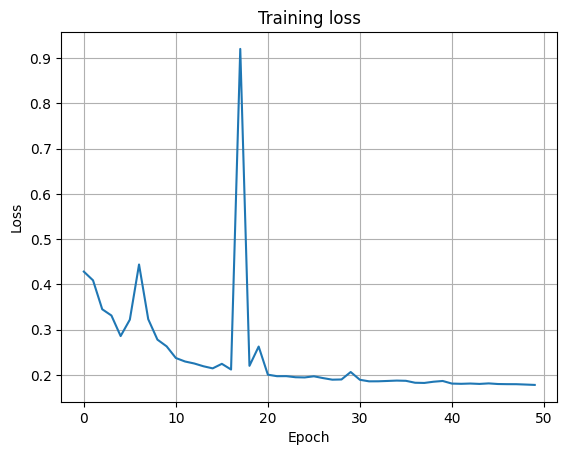

In [18]:
# Analys av hur träningen gick
import matplotlib.pyplot as plt

plt.plot(validation_losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training loss')
plt.grid(True)
plt.show()